## Module 4: General Linear Regression: Multiple Linear Regression and other regression models

### Step 0

Load the appropriate libraries and bring in the data. Note that we have to run a script to get the [California Housing dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) to match as it is in scikit-learn. We cannot pull it directly from scikit-learn since CodeGrade cannot access the internet.

In [1]:
# CodeGrade step0

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import os
import tarfile
import joblib # Import joblib directly
from sklearn.datasets._base import _pkl_filepath, get_data_home
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

archive_path = "cal_housing.tgz" # change the path if it's not in the current directory
data_home = get_data_home(data_home=None) # change data_home if you are not using ~/scikit_learn_data
if not os.path.exists(data_home):
    os.makedirs(data_home)
filepath = _pkl_filepath(data_home, 'cal_housing.pkz')

with tarfile.open(mode="r:gz", name=archive_path) as f:
    cal_housing = np.loadtxt(
        f.extractfile('CaliforniaHousing/cal_housing.data'),
        delimiter=',')
    # Columns are not in the same order compared to the previous
    # URL resource on lib.stat.cmu.edu
    columns_index = [8, 7, 2, 3, 4, 5, 6, 1, 0]
    cal_housing = cal_housing[:, columns_index]

    joblib.dump(cal_housing, filepath, compress=6) # Now using the directly imported joblib

# Load the dataset
california = fetch_california_housing(as_frame=True)
data = california.data
data['MedianHouseValue'] = california.target

Look at the data using `.info()` and `.describe()`.

In [2]:
# Display basic information
print(data.info())
print(data.describe())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MedInc            20640 non-null  float64
 1   HouseAge          20640 non-null  float64
 2   AveRooms          20640 non-null  float64
 3   AveBedrms         20640 non-null  float64
 4   Population        20640 non-null  float64
 5   AveOccup          20640 non-null  float64
 6   Latitude          20640 non-null  float64
 7   Longitude         20640 non-null  float64
 8   MedianHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      

### Step 1

Let the `X` variable be `MedInc`, `AveRooms`, and `HouseAge` and `y` be `MedianHouseValue`.

Then add the constant for the intercept.

Next, create the baseline model, called `baseline_model` using `smf.ols` for the above variables, and fit the model.

To verify the mdoel, return the $r^2$ value rounded to four decimal places.

In [3]:
# CodeGrade step1

# Define X and y
X = data[['MedInc', 'AveRooms', 'HouseAge']]
y = data['MedianHouseValue']

# Add constant for intercept
X_const = sm.add_constant(X)

# Fit baseline model
baseline_model = smf.ols('MedianHouseValue ~ MedInc + AveRooms + HouseAge', data=data).fit()

# Return R² rounded to 4 decimal places
round(baseline_model.rsquared, 4)

np.float64(0.5121)

Now print the model summary.

In [4]:
# Print model summary
print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:       MedianHouseValue   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     7220.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:00:18   Log-Likelihood:                -24836.
No. Observations:               20640   AIC:                         4.968e+04
Df Residuals:                   20636   BIC:                         4.971e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0204      0.022      0.928      0.3

### Step 2


Add a quadratic term to the data called `MedInc_squared`, which is what it sounds like.

Now fit the model using `smf.ols` with the quadratic term, calling this model, `nonlinear_model`. Make sure to incluce the variables  `MedInc`, `AveRooms`, and `HouseAge` as well.

To verify the model, return the $r^2$ value rounded to six decimal places.



In [5]:
# CodeGrade step2

# Add quadratic term
data['MedInc_squared'] = data['MedInc'] ** 2

# Fit nonlinear model
nonlinear_model = smf.ols('MedianHouseValue ~ MedInc + MedInc_squared + AveRooms + HouseAge', data=data).fit()

# Return R² rounded to 6 decimal places
round(nonlinear_model.rsquared, 6)

np.float64(0.52017)

Now print the model summary.

In [6]:
# Print the summary


### Step 3

Add (again) the same quadratic term, but now also add an interaction term that represents the interaction between `MedInc` and `AveRooms`.

Now fit the model using `smf.ols` with the quadratic term, calling this model, `interaction_model`.  Make sure to incluce the variables  `MedInc`, `AveRooms`, and `HouseAge` as well.

To verify the model, return the $r^2$ value rounded to six decimal places.

In [7]:
# CodeGrade step3

# Add quadratic term
data['MedInc_squared'] = data['MedInc'] ** 2

# Add interaction term as a column
data['MedInc_AveRooms'] = data['MedInc'] * data['AveRooms']

# Fit the model with the interaction term
interaction_model = smf.ols('MedianHouseValue ~ MedInc + MedInc_squared + AveRooms + HouseAge + MedInc_AveRooms', data=data).fit()

# Return R² rounded to 6 decimal places
round(interaction_model.rsquared, 6)

np.float64(0.520213)

Now print the model summary.

In [8]:
# Print the summary


### Step 4

Add (again) the same quadratic term as in the previous two steps.

Create an indicator variable by
1.   Find the median of `MedInc`, call this `median_income_threshold`
2.   Adding a new variable to the data set callede `HighIncome` that assigns a 1 to any value strictly greater than the median, and otherwise it assigns a 0.

Now fit the model using `smf.ols` with the quadratic term and indicator variable, calling this model, `indicator_model`.  Make sure to incluce the variables  `MedInc`, `AveRooms`, and `HouseAge` as well.

To verify the model, return the $r^2$ value rounded to six decimal places.

In [9]:
# CodeGrade step4

# Add quadratic term
data['MedInc_squared'] = data['MedInc'] ** 2

# Find median of MedInc
median_income_threshold = data['MedInc'].median()

# Create HighIncome indicator variable (1 if strictly greater than median, else 0)
data['HighIncome'] = np.where(data['MedInc'] > median_income_threshold, 1, 0)

# Fit indicator model
indicator_model = smf.ols('MedianHouseValue ~ MedInc + MedInc_squared + AveRooms + HouseAge + HighIncome', data=data).fit()

# Return R² rounded to 6 decimal places
round(indicator_model.rsquared, 6)

np.float64(0.520496)

Now print the model summary.

In [10]:
# Print the summary


### Step 5

Add (again) the same quadratic term, but now also add an log transformed term of `AveRooms` called `log_AveRooms`.

Now fit the model using `smf.ols` with the quadratic term, calling this model, `log_model`.  Make sure to incluce the variables  `MedInc`, `AveRooms`, and `HouseAge` as well.

To verify the model, return the $r^2$ value rounded to six decimal places.

In [11]:
# CodeGrade step5

# Add quadratic term
data['MedInc_squared'] = data['MedInc'] ** 2

# Apply log transformation to AveRooms
data['log_AveRooms'] = np.log(data['AveRooms'])

# Fit log model (replacing AveRooms with log_AveRooms)
log_model = smf.ols('MedianHouseValue ~ MedInc + MedInc_squared + log_AveRooms + HouseAge', data=data).fit()

# Return R² rounded to 6 decimal places
round(log_model.rsquared, 6)

np.float64(0.539497)

Now print the model summary.

In [12]:
# Print the summary


### Step 6

Return the shape of `log_model`'s residuals.

In [13]:
# CodeGrade step6

# Return shape of log_model residuals
log_model.resid.shape

(20640,)

Now for the log model, plot the resisuals vs. the fitted values and the Q-Q plot.

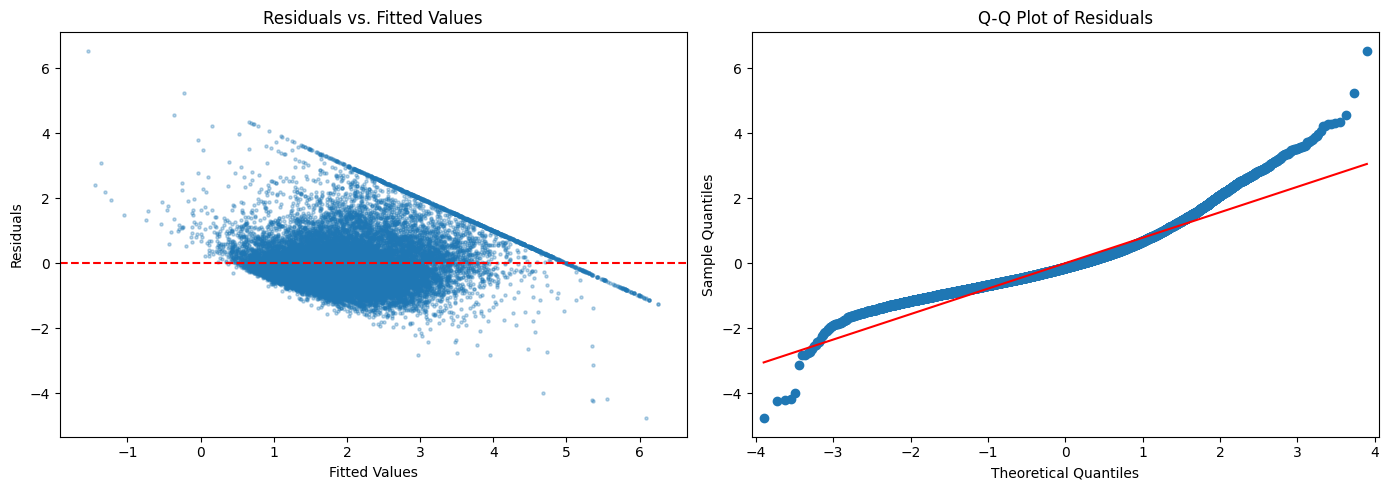

In [14]:
# Residuals vs. Fitted Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
fitted_vals = log_model.fittedvalues
residuals = log_model.resid
axes[0].scatter(fitted_vals, residuals, alpha=0.3, s=5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted Values')

# Q-Q Plot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()